# Author Popularity Analysis: Borrowings per Available Title
**Author**: Vuk

## Goal: 
In this analysis, we aim to indetify the authors, whose books are most frequently borrowed in relation to the number of different titles they have available in the library.

Rather than simply counting the total number of borrowings or available books, we calculate a borrowings-per-title ratio.
This metric helps us discover which authors consistently attract readers, even if they have only a few books on the shelves.

By focusing on this ratio, we can highlight not just the most prolific authors, but those whose limited works have a hish level of engagement and demand.

## Step 1: Import required libraries
We are going to use Pandas to load the data and Matplotlib and Seaborn to create the charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the dataset
We will use a dataset containing information about books:

catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,isbn,subjects,dimensions,thumbnail

In [2]:
df = pd.read_csv("books.csv")

## Step 3: Show some sample data
Show first 5 rows.

In [3]:
df.head()

,catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,isbn,subjects,dimensions,thumbnail
0,A1-B1-0001,Enormous Room,E. E. Cummings,1949,Drama,Fiction,5,3.0,6_Jan_25,4.14 out of 5 stars,2 ratings,$14.66,en,249.0,NaN,"Fiction, biographical, American fiction (ficti...",4.98 x 0.6 x 7.97 inches,http://books.google.com/books/content?id=mOGcE...
1,A1-B1-0002,Plutarchi Vitae parallelae,Plutarch,1478,Biography & Autobiography,History,4,1.0,19_Mar_24,No rating available,No reviews,$9.99,en,241.0,NaN,"Politics and government, Greek authors, Civili...",5.74 x 1.12 x 8.08 inches,NaN
2,A1-B1-0003,The water-babies,Charles Kingsley,1863,Fantasy,Children,6,6.0,5_Jun_24,4.21 out of 5 stars,6 ratings,$13.89,en,228.0,NaN,"Chimney sweeps, Open Library Staff Picks, Fict...",7.7 x 0.7 x 5.1 inches,NaN
3,A1-B1-0004,Kipps,H. G. Wells,1900,Comedy,Fiction,4,5.0,6_Nov_24,4.44 out of 5 stars,4 ratings,$370,eng,386.0,NaN,"Fiction, Young men, Working class, Orphans, Br...",5.08 x 0.98 x 7.8 inches,NaN
4,A1-B1-0005,Man and Superman,George Bernard Shaw,1903,Drama,Fiction,5,2.0,16_Jan_25,4.46 out of 5 stars,2 ratings,$10.99,en,220.0,NaN,"English Dramatists, English drama, Translation...",5.08 x 1.22 x 7.8 inches,NaN


## Step 4: Calculate thetotal number od titles per author and the total number of borrowings per author
We will gropu the data by authors, and then determine the number od books and the total number of borrowings for each resulting group.

In [4]:
inventory_gap  = (
    df.groupby('author')
      .agg(
          total_times_borrowed=('times_borrowed', 'sum'),
          available_titles=('title', 'count')
      )
      .sort_values(by='total_times_borrowed', ascending=False)
      .head(20)
)


## Step 5: Generate new column (copies_to_borrow_ratio)
We will generate a new column that represents the ratio between the total number of available books, per author.

In [5]:
inventory_gap['copies_to_borrow_ratio'] = inventory_gap['total_times_borrowed'] / inventory_gap['available_titles'] 

## Step 6: Get best 40 authors
We will sort the data in descending order so that the authors with the highset borrowings-to-title ratio appear at the top of the dataset. This will allow us to extract the top 40 authors.

In [6]:
inventory_gap = inventory_gap.sort_values(by=['copies_to_borrow_ratio'], ascending=False).reset_index()
top_40 = inventory_gap.head(40).reset_index()

## Step 7: Add the average value at the bottom for better understanding
We will add an additional row at the end of resulting dataset. It will represent the average value of the borrowings-to-available-books ratio. This will help us better perceive the results achived by the top authors.

In [7]:
avg_value = inventory_gap["copies_to_borrow_ratio"].mean()
average_row = pd.DataFrame([{
    "author": "[AVERAGE COPIES TO BORROW RATIO]",
    "copies_to_borrow_ratio": avg_value
}]).reindex(columns=top_40.columns)

combined_df = pd.concat([top_40, average_row], ignore_index=True)

## Step 8: Show results
We will use our data to create a bar plot that shows the final results. We will color all bars light blue, except for the last one, which will be orange.

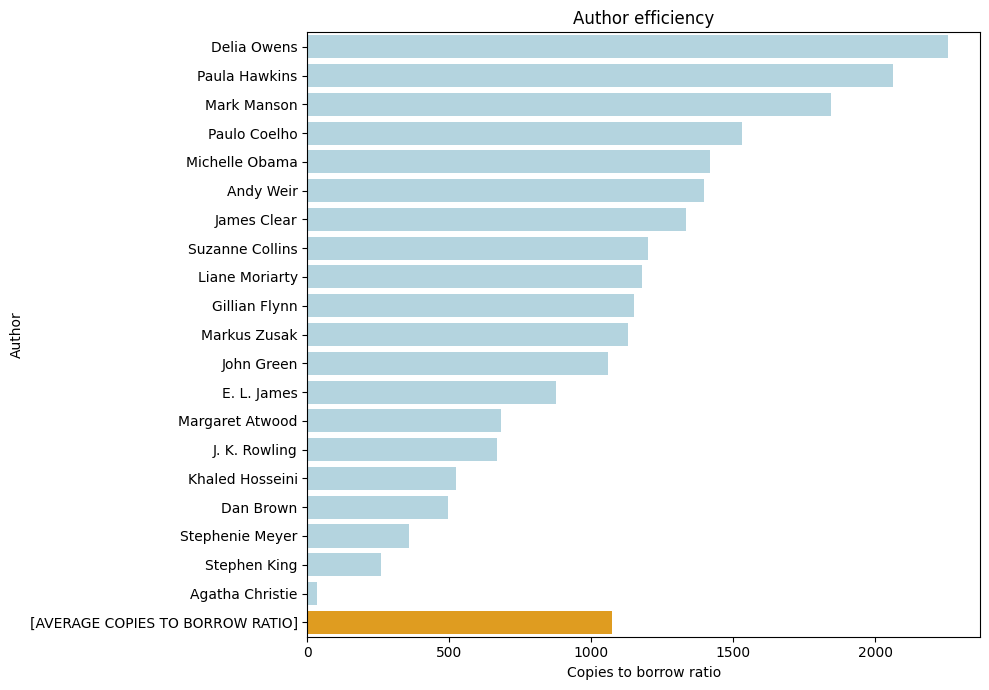

In [8]:
colors = ['lightblue'] * len(combined_df)
colors[-1] = "orange"

plt.figure(figsize=(10, 7))
sns.barplot(data=combined_df, x="copies_to_borrow_ratio", y="author",hue="author", palette=colors)
 
plt.title("Author efficiency")
plt.xlabel("Copies to borrow ratio")
plt.ylabel("Author")
plt.tight_layout()
plt.show()

## Conclusion:

This analysis hoghlights the most efficiently borrowed authors in the library-those whose works are borrowed frequently relative to the number of titles they ha ve available. Authors like Delia Owens, Paula Hawkins and Mark Manson stand out with exceptionaly high borrowings-to-titles ratios, indicating strong and consistent reader interest despite a limiterd number of books.

Adding the average ratio at the bootom of the chart provides useful context, helping us clearly see which authors singifucantly outperfom the average borrowings efficiency.

These insights can be valuable for:
- guidung future book acquisitions,
- indetifying authors with high demand,
- and understanding reading preferences in the library's user base.